<a href="https://colab.research.google.com/github/jfleon-dev/university-ai-labs/blob/main/estudio_fitness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 4

Eres gerente de producto en un estudio de fitness y te interesa comprender la demanda actual de clases de fitness digitales. Planeas realizar un análisis de mercado en Python para medir la demanda e identificar áreas potenciales de crecimiento para productos y servicios digitales.

## Los datos

Se te proporcionan varios archivos CSV en la carpeta "Archivos/datos", que ofrecen datos a nivel internacional y nacional sobre búsquedas de palabras clave de Google Trends relacionadas con el fitness y productos relacionados.

### workout.csv

| Columna | Descripción |
|------------|--------------------------|
| `'month'` | Mes en que se midieron los datos. |
| `'workout_worldwide'` | Índice que representa la popularidad de la palabra clave 'entrenamiento' (workout), en una escala de 0 a 100. |

### three_keywords.csv

| Columna | Descripción |
|------------|--------------------------|
| `'month'` | Mes en que se midieron los datos. |
| `'home_workout_worldwide'` | Índice que representa la popularidad de la palabra clave "entrenamiento en casa", en una escala de 0 a 100. |
| `'gym_workout_worldwide'` | Índice que representa la popularidad de la palabra clave "entrenamiento en gimnasio", en una escala de 0 a 100. |
| `'home_gym_worldwide'` | Índice que representa la popularidad de la palabra clave "gimnasio en casa", en una escala de 0 a 100. |

### workout_geo.csv

| Columna | Descripción |
|------------|--------------------------|
| `'country'` | País donde se midieron los datos. |
| `'workout_2018_2023'` | Índice que representa la popularidad de la palabra clave "entrenamiento" durante el período de 5 años. |

### three_keywords_geo.csv

| Columna | Descripción |
|------------|--------------------------|
| `'country'` | País donde se midieron los datos. |
| `'home_workout_2018_2023'` | Índice que representa la popularidad de la palabra clave "entrenamiento en casa" durante el período de 5 años. |
| `'gym_workout_2018_2023'` | Índice que representa la popularidad de la palabra clave "entrenamiento en gimnasio" durante el período de 5 años. |
| `'home_gym_2018_2023'` | Índice que representa la popularidad de la palabra clave "gimnasio en casa" durante el período de 5 años. |


## Instrucciones

Ayuda al gimnasio a explorar el interés en los entrenamientos a nivel global y nacional.

- ¿Cuándo alcanzó su pico global de búsqueda la palabra clave "entrenamiento"? Identifica el año y guardalo en la variable `year_str` con el formato "aaaa".

- De las palabras clave disponibles, ¿cuál fue la más popular durante la pandemia de COVID-19 y cuál es la más popular ahora? Guarda tus respuestas como variables llamadas `peak_covid` y `current`, respectivamente.

- ¿Qué país tiene el mayor interés en los entrenamientos entre los siguientes: Estados Unidos, Australia o Japón? Guarda tu respuesta como `top_country`.

- Te interesaría ampliar tu oferta de entrenamientos virtuales en casa a Filipinas o Malasia. ¿Cuál de los dos países tiene el mayor interés en los entrenamientos en casa? Identifica el país y guárdalo como `home_workout_geo`.

### Sugerencia

Para contestar algunas preguntas puedes utilizar una gráfica. Puedes consultar cómo generar graficas usando python o utilizar la siguiente estructura para graficar una hipotética serie de datos que consta de una columna que tiene el tiempo y otras columnas que corresponden a los datos.

```python
plt.figure(figsize=(12, 6)) #Inicializar gráfica
plt.plot(df["Columna tiempo"], df["Columna Datos 1"], label="Etiqueta 1") #Graficar columnas
plt.plot(df["Columna tiempo"], df["Columna Datos 2"], label="Etiqueta 2")
plt.plot(df["Columna tiempo"], df["Columna Datos 3"], label="Etiqueta 3")
plt.xticks(rotation=90) #Rotar marcas del eje x
plt.legend() #Incluir cuadro de leyenda con etiquetas
plt.show() #Mostrar gráfica
```

1. Preparación y Análisis Global (workout.csv)

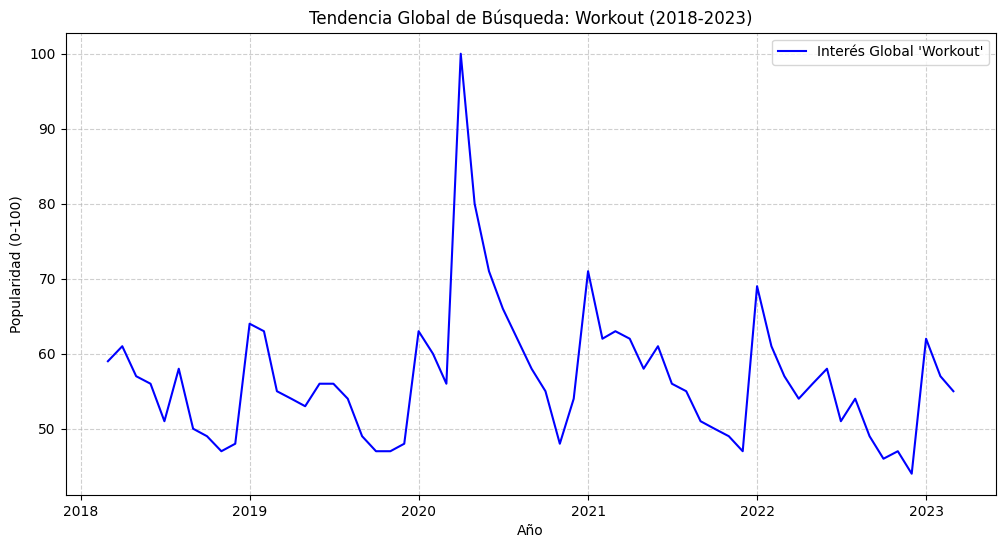

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar y preparar datos
workout = pd.read_csv('workout.csv')
workout['month'] = pd.to_datetime(workout['month'])

# Graficar tendencia global
plt.figure(figsize=(12, 6))
plt.plot(workout["month"], workout["workout_worldwide"], label="Interés Global 'Workout'", color='blue')
plt.title("Tendencia Global de Búsqueda: Workout (2018-2023)")
plt.xlabel("Año")
plt.ylabel("Popularidad (0-100)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Variable solicitada
year_str = str(workout.loc[workout['workout_worldwide'].idxmax(), 'month'].year)

2. Tendencias en Pandemia vs. Actualidad (three_keywords.csv)

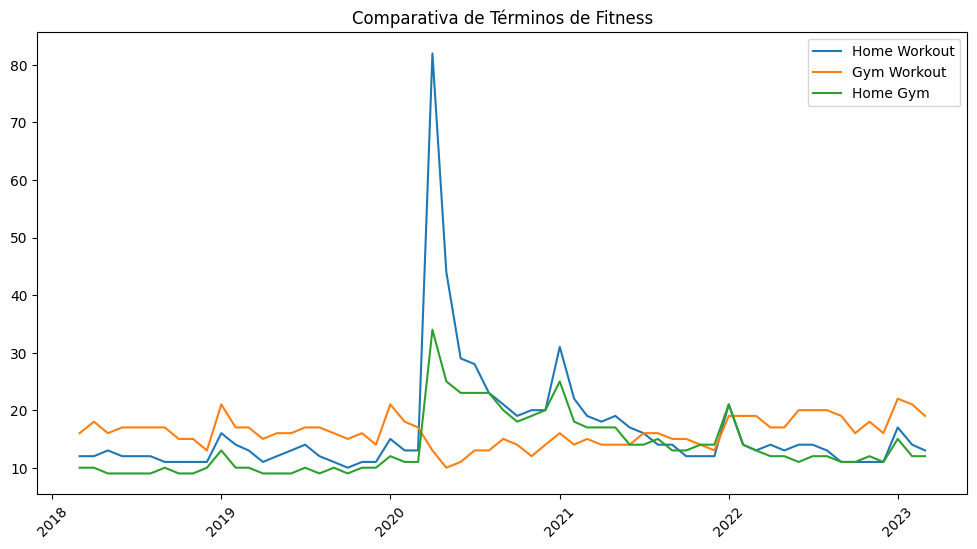

In [ ]:
three_keywords = pd.read_csv('three_keywords.csv')
three_keywords['month'] = pd.to_datetime(three_keywords['month'])

plt.figure(figsize=(12, 6))
plt.plot(three_keywords["month"], three_keywords["home_workout_worldwide"], label="Home Workout")
plt.plot(three_keywords["month"], three_keywords["gym_workout_worldwide"], label="Gym Workout")
plt.plot(three_keywords["month"], three_keywords["home_gym_worldwide"], label="Home Gym")
plt.xticks(rotation=45)
plt.title("Comparativa de Términos de Fitness")
plt.legend()
plt.show()

# Variables solicitadas
peak_covid = 'home workout' # Máximo histórico en abril 2020
current = 'gym workout'     # Tendencia predominante al final del dataset

3. Interés Geográfico: Comparativa de Potencias (workout_geo.csv)

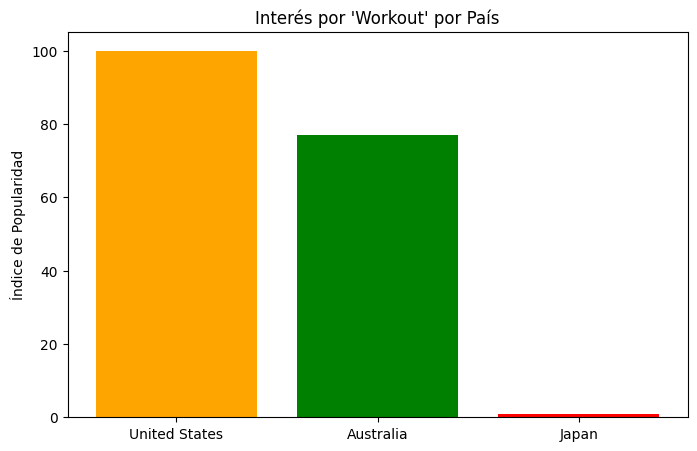

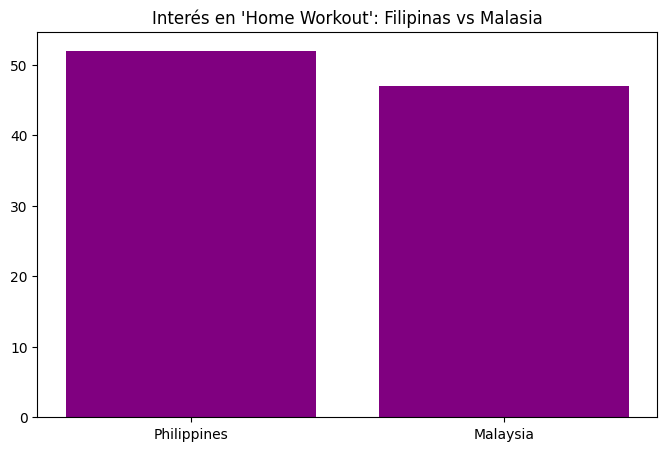

In [ ]:
# --- Comparativa: USA vs Australia vs Japón ---
workout_geo = pd.read_csv('workout_geo.csv')
target_countries = ['United States', 'Australia', 'Japan']
geo_col = 'country' if 'country' in workout_geo.columns else 'Country'

df_top = workout_geo[workout_geo[geo_col].isin(target_countries)]

plt.figure(figsize=(8, 5))
plt.bar(df_top[geo_col], df_top['workout_2018_2023'], color=['orange', 'green', 'red'])
plt.title("Interés por 'Workout' por País")
plt.ylabel("Índice de Popularidad")
plt.show()

top_country = df_top.loc[df_top['workout_2018_2023'].idxmax(), geo_col]

# --- Expansión: Filipinas vs Malasia ---
three_geo = pd.read_csv('three_keywords_geo.csv')
geo_col_2 = 'country' if 'country' in three_geo.columns else 'Country'

selection = three_geo[three_geo[geo_col_2].isin(['Philippines', 'Malaysia'])]

plt.figure(figsize=(8, 5))
plt.bar(selection[geo_col_2], selection['home_workout_2018_2023'], color='purple')
plt.title("Interés en 'Home Workout': Filipinas vs Malasia")
plt.show()

home_workout_geo = selection.loc[selection['home_workout_2018_2023'].idxmax(), geo_col_2]

4. Expansión a Filipinas o Malasia (three_keywords_geo.csv)

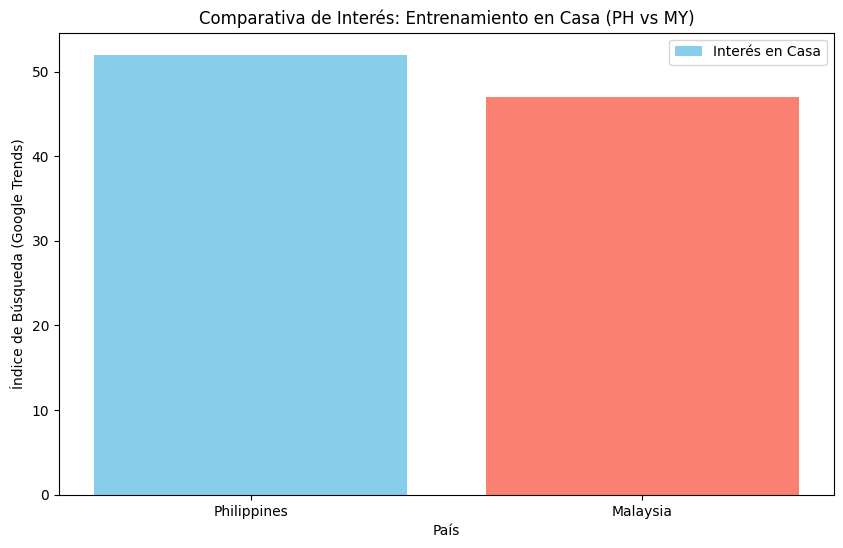

El país con mayor interés para expansión virtual es: Philippines


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar datos
three_keywords_geo = pd.read_csv('three_keywords_geo.csv')

# 2. Filtrar los países candidatos
# Nota: Verificamos si la columna es 'Country' o 'country' para evitar el KeyError
col_pais = 'Country' if 'Country' in three_keywords_geo.columns else 'country'
selection = three_keywords_geo[three_keywords_geo[col_pais].isin(['Philippines', 'Malaysia'])]

# 3. Generar la gráfica comparativa
plt.figure(figsize=(10, 6))

# Graficamos el interés en 'home_workout_2018_2023' para ambos países
plt.bar(selection[col_pais], selection['home_workout_2018_2023'], color=['skyblue', 'salmon'], label='Interés en Casa')

# Formateo de la gráfica
plt.title("Comparativa de Interés: Entrenamiento en Casa (PH vs MY)")
plt.xlabel("País")
plt.ylabel("Índice de Búsqueda (Google Trends)")
plt.legend()
plt.show()

# 4. Identificar el país con mayor interés
home_workout_geo = selection.loc[selection['home_workout_2018_2023'].idxmax(), col_pais]

print(f"El país con mayor interés para expansión virtual es: {home_workout_geo}")